# TP7 : Régression linéaire

Importez les bibliothèques suivantes.

In [31]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

Les TPs précédents portaient sur le K-clustering, la PCA, la NMF, le MDS, l'Isomap et le KNN. Le présent TP utilisant la PCA, voici une cellule important la classe `PCA` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)) de la bibliothèque `sklearn`. Regardez bien la documentation. Le nom des attributs et méthodes n'est pas nécessairement le même que dans les classes que nous avons nous même définies.

In [32]:
from sklearn.decomposition import PCA

Importez les jeux de données.

In [33]:
from google.colab import files
data_to_load = files.upload()
import io


df_pixels = pd.read_csv("pixels.csv")
X = df_pixels.to_numpy(dtype="float32")
df_prices = pd.read_csv("prix.csv")
y = df_prices.values

print(X.shape)
print(f"Nombre de prix : {len(y)}")
print(f"Prix min : {y.min():.2f}, Prix max : {y.max():.2f}")

Saving pixels.csv to pixels (1).csv
Saving prix.csv to prix (1).csv
(2535, 784)
Nombre de prix : 2535
Prix min : 25.94, Prix max : 194.54


---

## Introduction : de la classification à la régression

Dans le TP précédent, nous avons travaillé sur un problème de classification : prédire à quelle classe appartient une image (T-shirt, pantalon, robe, etc.). La sortie du modèle était une étiquette discrète parmi un ensemble fini de classes.

Nous abordons maintenant la régression : prédire une valeur continue. Dans notre cas, il s'agit de prédire le prix d'un vêtement à partir de l'image. La sortie du modèle est un nombre réel.

Le modèle le plus simple de régression est la régression linéaire. L'idée est de trouver un vecteur de poids tel que la prédiction pour une entrée donnée soit une combinaison linéaire des caractéristiques d'entrée.

Pour un jeu de données d'entraînement (matrice où chaque ligne est un exemple) et un vecteur des sorties cibles, le vecteur de poids optimal au sens des moindres carrés est donné par les équations normales. Cette formule suppose que la matrice des données soit de rang plein (toutes les colonnes sont linéairement indépendantes).

L'objectif de ce TP va consister en la création d'une classe permettant l'entraînement et la prédiction d'un modèle de régression linéaire. Nous allons la construire pas à pas grâce à la méthode du Monkey-Patching.

In [34]:
class MyLinearRegression:
    def __init__(self):
        # Attributs qui seront remplis lors de l'entraînement
        self.weights = None
        self.data = None
        self.output = None

print("Classe initialisée.")

Classe initialisée.


## Exercice 1

1. Ajoutez à la classe MyLinearRegression une méthode `fit(self, data, output)` qui vérifie si data est de rang plein en utilisant `np.linalg.matrix_rank` (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.matrix_rank.html)**). Si le rang est strictement inférieur au nombre de colonnes, afficher un message d'erreur avec le rang et ne rien faire d'autre. Si le rang est plein, calculer `self.weights` avec les équations normales : $$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$ en utilisant np.linalg.inv ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html)) et stocker `data` et `output` dans `self.data` et `self.output`.

In [35]:
def fit(self, data, output):
    rang = np.linalg.matrix_rank(data)
    if rang < data.shape[1]:
        print(f"Erreur, la matrice n'est pas de rang plein (rang = {rang}, colonnes = {data.shape[1]}).")
        return
    self.data = data
    self.output = output
    self.weights = np.linalg.inv(data.T @ data) @ data.T @ output

MyLinearRegression.fit = fit
print("Méthode fit ajoutée.")
MyLinearRegression.fit = fit

Méthode fit ajoutée.


2. Ajoutez une méthode `predict(self, data)` qui retourne les prédictions du modèle en utilisant les poids appris sur une matrice de données `data`.

In [36]:
def predict(self, data):
    return data @ self.weights

MyLinearRegression.predict = predict
print("Méthode predict ajoutée.")

Méthode predict ajoutée.


3. Ajoutez une méthode `mse(self)` qui calcule et retourne l'erreur quadratique moyenne (Mean Squared Error) entre `self.output` et les prédictions sur `self.data` : $$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

In [37]:
def mse(self):
    prediction = self.predict(self.data)
    erreurCarree = (self.output - prediction) ** 2
    return np.mean(erreurCarree)

MyLinearRegression.mse = mse
print("Méthode mse ajoutée.")

Méthode mse ajoutée.


4. Ajoutez une méthode `r2(self)` qui calcule et retourne le coefficient de détermination $R^2$ entre `self.output` et les prédictions sur `self.data` : $$R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}$$ où $\bar{y}$ est la moyenne de y. Un $R^2$ de 1 indique une prédiction parfaite, un $R^2$ de 0 indique que le modèle ne fait pas mieux que prédire la moyenne, un $R^2$ négatif signifie que le modèle est moins performant que la prédiction constante à la moyenne.

In [38]:
def r2(self):
    prediction = self.predict(self.data)
    sommeResidus = np.sum((self.output - prediction) ** 2)
    sommeTotale = np.sum((self.output - np.mean(self.output)) ** 2)
    return 1 - sommeResidus / sommeTotale

MyLinearRegression.r2 = r2
print("Méthode r2 ajoutée.")

Méthode r2 ajoutée.


## Exercice 2

Créez une instance de MyLinearRegression, entraînez-la sur `X` et `y`, et observez ce qui se passe. Pourquoi l'entraînement échoue-t-il ? Réfléchissez à ce que signifie dans le contexte de notre dataset d'images de vêtements.

In [39]:
model = MyLinearRegression()
model.fit(X, y)

Erreur, la matrice n'est pas de rang plein (rang = 671, colonnes = 784).


L’entraînement échoue car la matrice X n’est pas de rang plein. Cela signifie que certaines colonnes (pixels) sont dépendantes linéairement. Comme les images ont beaucoup de pixels, il y a trop de variables par rapport au nombre d’exemples. La matrice XᵀX n’est donc pas inversible.

## Exercice 3

Une première approche pour résoudre le problème de rang consiste à projeter `X` dans un espace de dimension réduite en utilisant la PCA. Si on ne garde que $r$ composantes principales avec $r$ strictement inférieur au rang de `X`, alors la matrice projetée est garantie d'être de rang plein.

1. Utilisez la classe PCA de `sklearn` pour projeter `X` sur $r = 50$ composantes. Entraînez ensuite une `MyLinearRegression` sur les données projetées. Affichez le MSE et le $R^2$ obtenus. Les résultats vous semblent-ils satisfaisants ?

In [40]:
r = 50
pca = PCA(n_components=r)
Xpca = pca.fit_transform(X)

model_pca = MyLinearRegression()
model_pca.fit(Xpca, y)
print(f"MSE  = {model_pca.mse():.4f}")
print(f"R²   = {model_pca.r2():.4f}")

MSE  = 7938.3101
R²   = -5.3413


2. Testez différentes valeurs de $r : 5, 10, 20, 50, 100, 200, 300,600$. Pour chaque valeur, projetez `X` avec PCA avec $r$ composantes, entraînez une `MyLinearRegression` sur les données projetées, et stockez le MSE et le $R^2$. Tracez deux courbes : MSE en fonction de $r$ et $R^2$ en fonction de $r$. Les performances s'améliorent-elles significativement avec plus de composantes ?

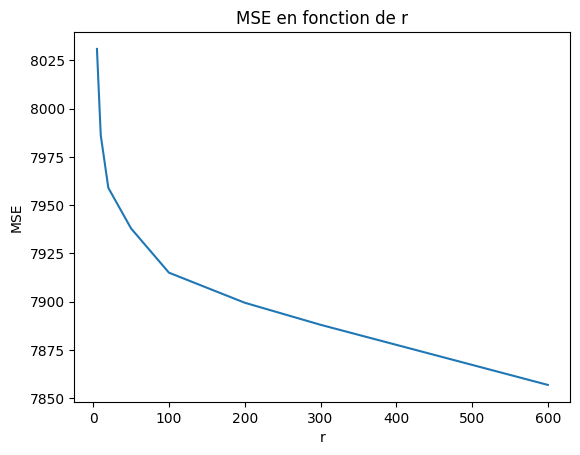

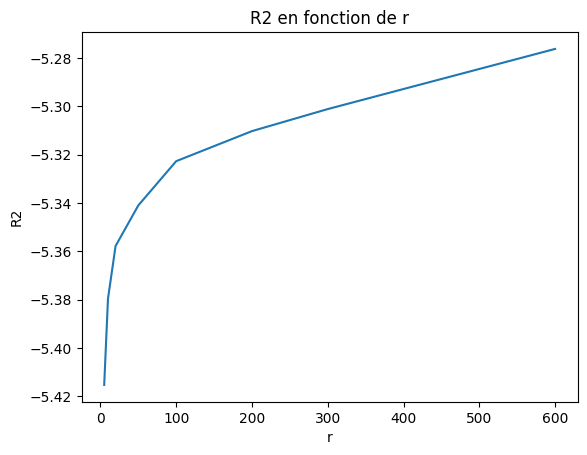

r=   5 | MSE=8030.9745 | R2=-5.4153
r=  10 | MSE=7986.3012 | R2=-5.3796
r=  20 | MSE=7959.0112 | R2=-5.3578
r=  50 | MSE=7937.9855 | R2=-5.3410
r= 100 | MSE=7915.0530 | R2=-5.3227
r= 200 | MSE=7899.4822 | R2=-5.3103
r= 300 | MSE=7888.0571 | R2=-5.3012
r= 600 | MSE=7856.9001 | R2=-5.2763


In [41]:
valeursr = [5, 10, 20, 50, 100, 200, 300, 600]
listeMSE = []
listeR2 = []

for r in valeursr:
    pca = PCA(n_components=r)
    donneesprojetees = pca.fit_transform(X)

    modele = MyLinearRegression()
    modele.fit(donneesprojetees, y)

    listeMSE.append(modele.mse())
    listeR2.append(modele.r2())

plt.figure()
plt.plot(valeursr, listeMSE)
plt.xlabel("r")
plt.ylabel("MSE")
plt.title("MSE en fonction de r")
plt.show()

plt.figure()
plt.plot(valeursr, listeR2)
plt.xlabel("r")
plt.ylabel("R2")
plt.title("R2 en fonction de r")
plt.show()

for r, mseval, r2val in zip(valeursr, listeMSE, listeR2):
    print(f"r={r:4d} | MSE={mseval:.4f} | R2={r2val:.4f}")

Les performances s'améliorent légèrement avec l'augmentation de r, mais de façon limitée. Le MSE diminue et le R2 augmente quand on ajoute des composantes, mais R² reste négatif). Ce qui montre que même avec plus de composantes, le modèle ne capture pas bien la relation entre pixels et prix.

3. Pour comprendre ce qui se passe, calculez la moyenne des prédictions du modèle sur X_pca et comparez-la avec la moyenne des vrais prix y. Que remarquez-vous ? Quelle est l'origine de ce problème ?

In [42]:
pca = PCA(n_components=50)
Xpca = pca.fit_transform(X)

model_pca = MyLinearRegression()
model_pca.fit(Xpca, y)

print("Moyenne prédictions :", np.mean(model_pca.predict(Xpca)))
print("Moyenne vrais prix :", np.mean(y))

Moyenne prédictions : -3.0298118457169497e-06
Moyenne vrais prix : 87.87445759368836


L’ajout d’un biais améliore le modèle car il permet d’ajuster la moyenne des prédictions à la moyenne réelle des prix. Sans intercept, le modèle est forcé de passer par l’origine ce qui entraîne des prédictions  autour de zéro. Avec le biais, le modèle peut mieux capturer le niveau moyen des données, ce qui réduit l’erreur et améliore le R².

## Exercice 4

La régression Ridge est une variante de la régression linéaire qui ajoute un terme de régularisation. Les équations normales deviennent :
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}$$

où $\lambda > 0$ est le paramètre de régularisation et $\mathbf{I}$ est la matrice identité. L'ajout de $\lambda \mathbf{I}$ garantit que la matrice est inversible même si $X$ n'est pas de rang plein.

1. Créez une classe `MyRidgeRegression` avec la même structure que MyLinearRegression, mais dont la méthode fit prend un paramètre supplémentaire lambda_param et utilise la formule Ridge ci-dessus. Vous pouvez réutilisez les autres méthodes. Testez votre implémentation avec `lambda_param = 1.0` sur `X` et `y`. Affichez le MSE et le $R^2$.

In [43]:
class MyRidgeRegression(MyLinearRegression):
    def fit(self, data, output, lambda_param=1.0):
        self.data = data
        self.output = output
        n_features = data.shape[1]
        self.weights = np.linalg.inv(data.T @ data + lambda_param * np.eye(n_features)) @ data.T @ output

ridge = MyRidgeRegression()
ridge.fit(X, y, lambda_param=1.0)
print(f"MSE  = {ridge.mse():.4f}")
print(f"R²   = {ridge.r2():.4f}")


MSE  = 191.6238
R²   = 0.8469


2. Testez différentes valeurs de lambda $\lambda : 0.001, 0.01, 0.1, 1, 10, 100, 1000$. Pour chaque valeur, entraînez un modèle et stockez le MSE et le $R^2$ correspondants. Tracez deux courbes (échelle logarithmique pour l'axe des $x$) : MSE en fonction de $\lambda$ et $R^2$ en fonction de $\lambda$. Comment évoluent les performances en fonction de $\lambda$ ? Quelle valeur de $\lambda$ donne les meilleurs résultats sur ce dataset ?

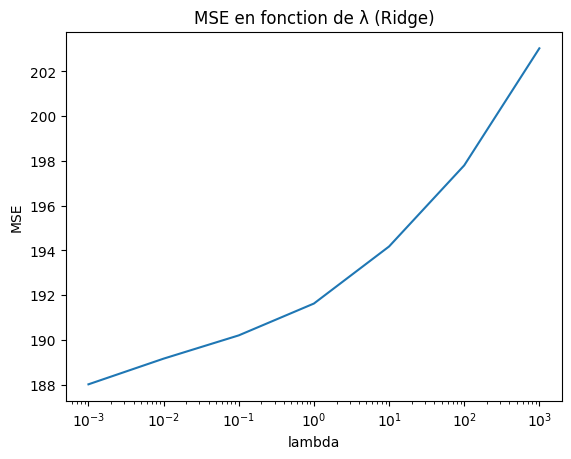

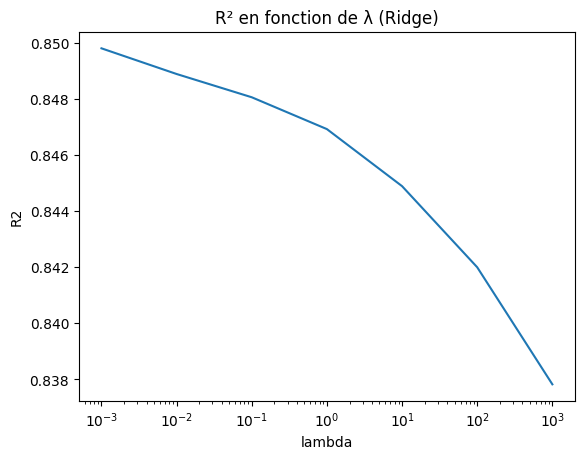

λ=   0.001 | MSE=188.0146 | R²=0.8498
λ=   0.010 | MSE=189.1619 | R²=0.8489
λ=   0.100 | MSE=190.2014 | R²=0.8481
λ=   1.000 | MSE=191.6238 | R²=0.8469
λ=  10.000 | MSE=194.1725 | R²=0.8449
λ= 100.000 | MSE=197.7962 | R²=0.8420
λ=1000.000 | MSE=203.0266 | R²=0.8378


In [44]:
lambdav = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
mselist = []
r2list = []

for l in lambdav:
    model = MyRidgeRegression()
    model.fit(X, y, lambda_param=l)

    mselist.append(model.mse())
    r2list.append(model.r2())

plt.figure()
plt.semilogx(lambdav, mselist)
plt.xlabel("lambda")
plt.ylabel("MSE")
plt.title('MSE en fonction de λ (Ridge)')
plt.show()

plt.figure()
plt.semilogx(lambdav, r2list)
plt.xlabel("lambda")
plt.ylabel("R2")
plt.title('R² en fonction de λ (Ridge)')
plt.show()

for lam, mse_val, r2_val in zip(lambdav, mselist, r2list):
    print(f"λ={lam:8.3f} | MSE={mse_val:.4f} | R²={r2_val:.4f}")

Lorsque λ est très faible, le modèle Ridge est presque équivalent à une régression linéaire classique, car la pénalisation reste minime. Pour des valeurs plus élevées de λ, les coefficients sont davantage contraints et se rapprochent de zéro, ce qui réduit la capacité du modèle à bien prédire et dégrade les performances.

Les meilleurs résultats (avec un MSE plus faible et un R² plus élevé) apparaissent pour des valeurs petites de λ, comme 0.001 ou 0.01. Ces valeurs permettent de stabiliser l’inversion de la matrice sans trop restreindre les poids.

## Exercice 5

Jusqu'ici, notre modèle de régression prédit une sortie comme une combinaison linéaire des entrées, sans terme constant. Ce modèle passe forcément par l'origine : si toutes les entrées sont nulles, alors la sortie prédite est nulle. En pratique, on souhaite souvent un modèle affine qui inclut un biais (intercept).

Une astuce classique consiste à ajouter une colonne de $1$ à la matrice de données, ce qui permet d'absorber le biais dans le vecteur de poids.

1. Créez une nouvelle matrice X_affine en ajoutant une colonne de $1$ à `X` avec np.c_ (**[documentation](https://numpy.org/doc/stable/reference/generated/numpy.c_.html)**). Entraînez un modèle `MyRidgeRegression` avec `lambda = 1.0` sur `X` et sur `X_affine`, et comparez les MSE et $R^2$ obtenus.

In [45]:
X_affine = np.c_[np.ones(X.shape[0]), X]

ridge1 = MyRidgeRegression()
ridge1.fit(X, y, 1.0)

ridge2 = MyRidgeRegression()
ridge2.fit(X_affine, y, 1.0)

print("Sans intercept MSE :", ridge1.mse())
print("Avec intercept MSE :", ridge2.mse())

print("Sans intercept R2 :", ridge1.r2())
print("Avec intercept R2 :", ridge2.r2())

Sans intercept MSE : 191.6237751398014
Avec intercept MSE : 117.47498386577769
Sans intercept R2 : 0.8469267566604743
Avec intercept R2 : 0.9061584253912447


2. Faites de même avec la PCA : projetez X sur $r = 50$ composantes, puis créez deux versions : une sans colonne de $1$ et une avec colonne de $1$. Entraînez une `MyLinearRegression` sur chacune et comparez les résultats. Que constatez-vous ? L'ajout de l'intercept améliore-t-il significativement les résultats ? Pourquoi ?

In [46]:
r = 50
pca = PCA(n_components=r)
X_pca = pca.fit_transform(X)
modele = MyLinearRegression()
modele.fit(X_pca, y)

print("=== PCA sans intercept ===")
print("MSE :", modele.mse())
print("R2  :", modele.r2())


X_pcabiais = np.c_[np.ones(X_pca.shape[0]), X_pca]

modelebiais = MyLinearRegression()
modelebiais.fit(X_pcabiais, y)

print("\n=== PCA avec intercept ===")
print("MSE :", modelebiais.mse())
print("R2  :", modelebiais.r2())

=== PCA sans intercept ===
MSE : 7937.684560904004
R2  : -5.340795235127802

=== PCA avec intercept ===
MSE : 215.76484343001792
R2  : 0.8276423457455531


Sans intercept, le modèle obtient un R² négatif et un MSE élevé. Avec l’intercept, le MSE diminue fortement et le R² augmente significativement.
L’ajout de l’intercept améliore donc nettement les résultats, car le modèle n’est plus contraint de passer par l’origine. Même après réduction de dimension par PCA, le biais reste nécessaire pour bien ajuster les données.

3. Maintenant que nous avons compris l'importance de l'intercept, étudiez l'impact du paramètre $\lambda$ pour Ridge avec intercept. Testez les mêmes valeurs que précédemment $(0.001, 0.01, 0.1, 1, 10, 100, 1000)$ mais cette fois sur `X_affine`. Tracez les courbes MSE et $R^2$ en fonction de $\lambda$.

lambda=  0.001 | MSE=203.0266 | R2=0.8378
lambda=   0.01 | MSE=203.0266 | R2=0.8378
lambda=    0.1 | MSE=203.0266 | R2=0.8378
lambda=      1 | MSE=203.0266 | R2=0.8378
lambda=     10 | MSE=203.0266 | R2=0.8378
lambda=    100 | MSE=203.0266 | R2=0.8378
lambda=   1000 | MSE=203.0266 | R2=0.8378


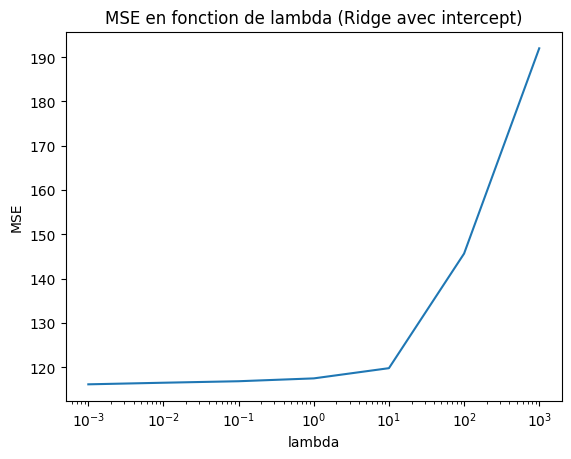

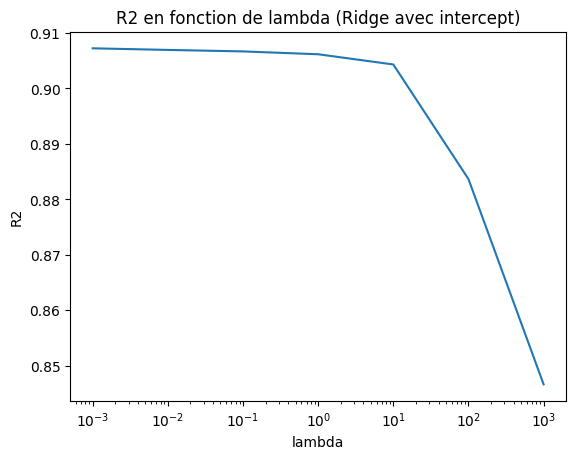

In [47]:
valeursl= [0.001, 0.01, 0.1, 1, 10, 100, 1000]

mseliste = []
r2liste= []

for l in valeursl:
    modele = MyRidgeRegression()
    modele.fit(X_affine, y, lambda_param=l)

    mseliste.append(modele.mse())
    r2liste.append(modele.r2())

    print(f"lambda={l:7} | MSE={model.mse():.4f} | R2={model.r2():.4f}")
plt.figure()
plt.semilogx(valeursl, mseliste)
plt.xlabel("lambda")
plt.ylabel("MSE")
plt.title("MSE en fonction de lambda (Ridge avec intercept)")
plt.show()

plt.figure()
plt.semilogx(valeursl, r2liste)
plt.xlabel("lambda")
plt.ylabel("R2")
plt.title("R2 en fonction de lambda (Ridge avec intercept)")
plt.show()

4. De même, étudiez l'impact du nombre de composantes PCA avec intercept. Testez les mêmes valeurs que précédemment $(5, 10, 20, 50, 100, 200, 300, 600)$ mais cette fois en ajoutant systématiquement une colonne de $1$ après la projection PCA. Tracez les courbes MSE et $R^2$ en fonction de $r$.

r =    5 | MSE = 309.0536 | R2 = 0.7531
r =   10 | MSE = 264.3683 | R2 = 0.7888
r =   20 | MSE = 237.0989 | R2 = 0.8106
r =   50 | MSE = 215.7204 | R2 = 0.8277
r =  100 | MSE = 194.0153 | R2 = 0.8450
r =  200 | MSE = 178.7180 | R2 = 0.8572
r =  300 | MSE = 165.0670 | R2 = 0.8681
r =  600 | MSE = 134.7916 | R2 = 0.8923


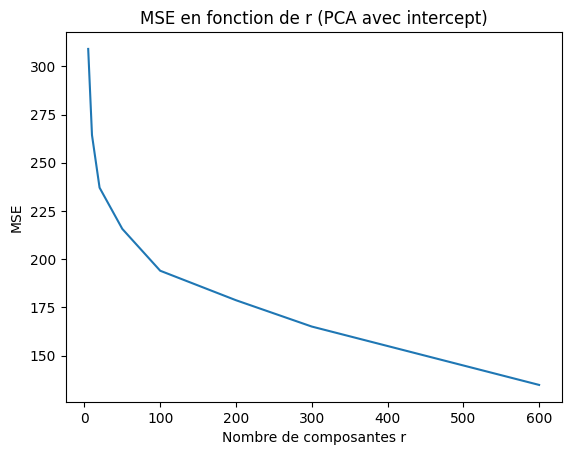

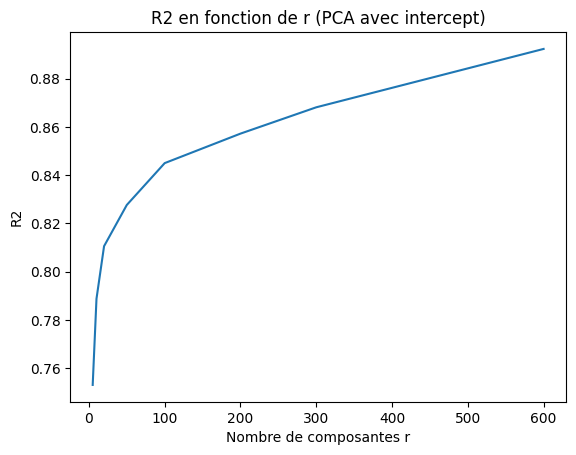

In [48]:
valeursr = [5, 10, 20, 50, 100, 200, 300, 600]

listeMSE = []
listeR2 = []

for r in valeursr:
    pca = PCA(n_components=r)
    donneesprojetees = pca.fit_transform(X)
    donneesaffines = np.c_[np.ones(donneesprojetees.shape[0]), donneesprojetees]
    modele = MyLinearRegression()
    modele.fit(donneesaffines, y)
    mse = modele.mse()
    r2 = modele.r2()
    listeMSE.append(mse)
    listeR2.append(r2)

    print(f"r = {r:4d} | MSE = {mse:.4f} | R2 = {r2:.4f}")


plt.figure()
plt.plot(valeursr, listeMSE)
plt.xlabel("Nombre de composantes r")
plt.ylabel("MSE")
plt.title("MSE en fonction de r (PCA avec intercept)")
plt.show()


plt.figure()
plt.plot(valeursr, listeR2)
plt.xlabel("Nombre de composantes r")
plt.ylabel("R2")
plt.title("R2 en fonction de r (PCA avec intercept)")
plt.show()

5. Comparez les résultats des deux exercices précédents. Quelle approche (Ridge ou PCA) donne les meilleurs résultats avec intercept ? Quelle valeur optimale de $\lambda$ ou r observez-vous ?

Les deux méthodes s’améliorent clairement quand on ajoute un intercept. Mais en comparant les résultats, la régression Ridge avec intercept donne de meilleurs scores que la régression après PCA.

Avec la PCA, plus on augmente le nombre de composantes r, plus le MSE baisse et le R² augmente. Les meilleures performances apparaissent pour des valeurs élevées de r, comme 300 ou 600, car on garde plus d’information des images. Malgré ça, les résultats restent en dessous de ceux obtenus avec Ridge.

Avec la Ridge, on utilise toutes les variables tout en stabilisant le calcul grâce à la régularisation. Les meilleures performances sont observées pour des valeurs de λ petites ou intermédiaires, par exemple autour de 0.001, 0.01 ou 1 selon les résultats.

Au final, la Ridge avec intercept est la méthode la plus performante sur ce dataset.